# Classifieur d'intention : baseline TF-IDF + LogReg

## Imports

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
import joblib, json, datetime
import sklearn


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

## Configuration

**3 datasets d'entraînement** (un par LLM générateur), **1 dataset de test** (générateur différent).  
Le split train/test est fait par générateur afin de mesurer la capacité du modèle à généraliser à des formulations produites par un LLM jamais vu à l'entraînement.

In [2]:
TRAIN_PATHS = [
    "data/classifieur/dataset_train_CLAUDE_opus5.csv",
    "data/classifieur/dataset_train_CLAUDE_opus48.csv",
    "data/classifieur/dataset_train_GPT_luna.csv",
]
TEST_PATH = "data/classifieur/dataset_test_GEMINI_15pro.csv"

# Ordre canonique = ordre de priorité en cas d'ambiguïté (cf. perimetre-intentions §Principe).
# On l'impose partout pour que les 2 classes de sécurité soient en haut/à gauche de la matrice.
CLASS_ORDER = [
    "detresse_urgence",
    "restriction_alimentaire",
    "out_of_scope",
    "food_specific",
    "in_scope",
]
SAFETY_CLASSES = ["detresse_urgence", "restriction_alimentaire"]

### Chargement des données pour le train

In [4]:
frames = []
for path in TRAIN_PATHS:
    df = pd.read_csv(path)
    frames.append(df)
    print(f"{path:35s} -> {len(df)} lignes")

df_train = pd.concat(frames, ignore_index=True)
print(f"\nTotal train : {len(df_train)} lignes")
df_train.head()

data/classifieur/dataset_train_CLAUDE_opus5.csv -> 125 lignes
data/classifieur/dataset_train_CLAUDE_opus48.csv -> 125 lignes
data/classifieur/dataset_train_GPT_luna.csv -> 125 lignes

Total train : 375 lignes


,id_cat,name_cat,question,generator
0,1,detresse_urgence,"La douleur m'a réveillée cette nuit et elle ne passe pas malgré les antidouleurs, qu'est-ce que je peux faire ?",[Claude_Opus-5]
1,1,detresse_urgence,"Je n'arrive plus à aller travailler tellement les crises sont violentes, je ne sais plus comment tenir.",[Claude_Opus-5]
2,1,detresse_urgence,"Mon ventre est dur et j'ai des frissons depuis ce matin, dois-je consulter en urgence ?",[Claude_Opus-5]
3,1,detresse_urgence,"J'ai tellement mal que je n'arrive plus rien à avaler, est-ce qu'il existe quelque chose pour me soulager tout de su...",[Claude_Opus-5]
4,1,detresse_urgence,"Je suis seule chez moi et la douleur devient insupportable, vers qui me tourner maintenant ?",[Claude_Opus-5]


### Chargement des données de test
Controle au passage que même noms de colonnes et pas de NaN

In [6]:
df_test = pd.read_csv(TEST_PATH)
print(f"Total test : {len(df_test)} lignes\n")

expected = {"id_cat", "name_cat", "question", "generator"}
print("Colonnes train OK :", set(df_train.columns) == expected, "|", list(df_train.columns))
print("Colonnes test  OK :", set(df_test.columns)  == expected, "|", list(df_test.columns))

print("\nNaN train :", df_train.isna().sum().to_dict())
print("NaN test  :", df_test.isna().sum().to_dict())

Total test : 125 lignes

Colonnes train OK : True | ['id_cat', 'name_cat', 'question', 'generator']
Colonnes test  OK : True | ['id_cat', 'name_cat', 'question', 'generator']

NaN train : {'id_cat': 0, 'name_cat': 0, 'question': 0, 'generator': 0}
NaN test  : {'id_cat': 0, 'name_cat': 0, 'question': 0, 'generator': 0}


## Exploration
### Vérification de la répartition des classes

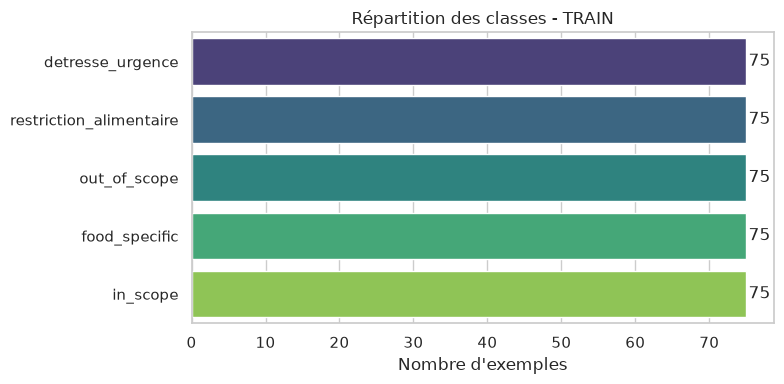

In [17]:
# Attendu : équilibré, 25 par classe × 3 générateurs = 75 par classe.
counts_train = df_train["name_cat"].value_counts().reindex(CLASS_ORDER)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=counts_train.values, y=counts_train.index,
            hue=counts_train.index, palette="viridis", legend=False, ax=ax)
ax.set(title="Répartition des classes - TRAIN", xlabel="Nombre d'exemples", ylabel="")
for i, v in enumerate(counts_train.values):
    ax.text(v + 0.3, i, str(v), va="center")
plt.tight_layout(); plt.show()

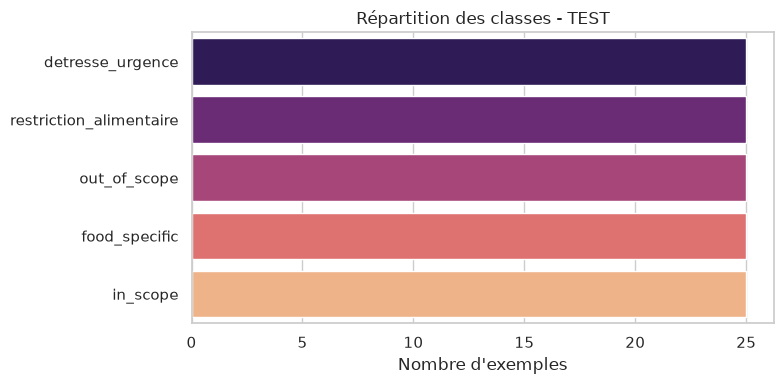

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

counts_test = df_test["name_cat"].value_counts().reindex(CLASS_ORDER)
sns.barplot(x=counts_test.values, y=counts_test.index,
            hue=counts_test.index, palette="magma", legend=False, ax=ax)
ax.set(title="Répartition des classes - TEST", xlabel="Nombre d'exemples", ylabel="")
plt.tight_layout(); plt.show()

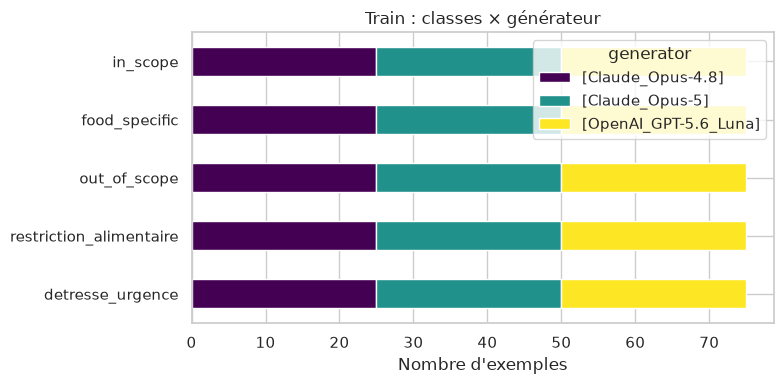

In [18]:
# Chaque LLM couvre-t-il bien chaque classe
fig, ax = plt.subplots(figsize=(8, 4))

pivot = df_train.pivot_table(index="name_cat", columns="generator",
                             values="question", aggfunc="count").reindex(CLASS_ORDER)
pivot.plot(kind="barh", stacked=True, colormap="viridis", ax=ax)
ax.set(title="Train : classes × générateur", xlabel="Nombre d'exemples", ylabel="")
plt.tight_layout(); plt.show()

### Longueur des questions par classes 
Le périmètre envoyé au llm impose des registres variés (questions de 1-5 mots et longs témoignages).  
Vérification de cette diversité et si la longueur diffère par classe. Par exemple si les témoignages de détresse sont systématiquement longs, le modèle risque d'apprendre la longueur comme raccourci.

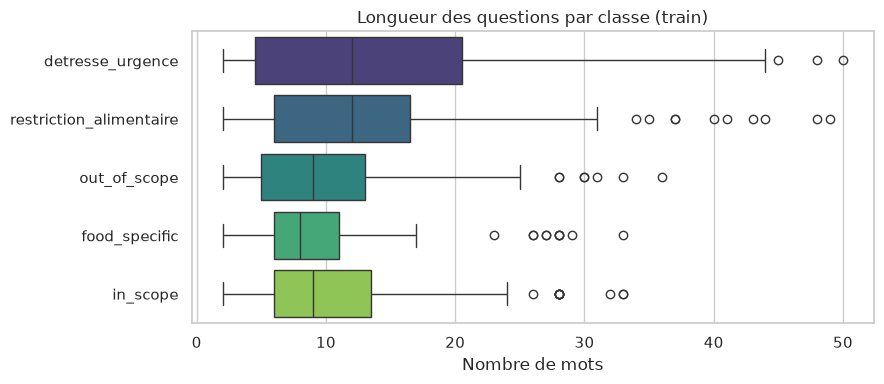

,mean,min,max
name_cat,,,
detresse_urgence,15.600000,2,50
restriction_alimentaire,14.973333,2,49
out_of_scope,10.840000,2,36
food_specific,10.066667,2,33
in_scope,11.520000,2,33


In [19]:
df_train["n_words"] = df_train["question"].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df_train, x="n_words", y="name_cat", order=CLASS_ORDER,
            hue="name_cat", palette="viridis", legend=False, ax=ax)
ax.set(title="Longueur des questions par classe (train)", xlabel="Nombre de mots", ylabel="")
plt.tight_layout(); plt.show()

df_train.groupby("name_cat")["n_words"].agg(["mean", "min", "max"]).reindex(CLASS_ORDER)

### Controle des fuites entre train et test
Générateurs différents donc les doublons exacts sont improbables, mais les questions très courtes du type "tomates ? peuvent coïncider. Une fuite gonflerait artificiellement le score de test.


In [20]:
def norm(s):
    return s.str.lower().str.strip()

overlap = set(norm(df_train["question"])) & set(norm(df_test["question"]))
print(f"Questions identiques train/test : {len(overlap)}")
for q in list(overlap)[:10]:
    print("  -", q)

print(f"\nDoublons internes au train : {df_train['question'].pipe(norm).duplicated().sum()}")

Questions identiques train/test : 0

Doublons internes au train : 3


## Baseline

In [21]:
X_train, y_train = df_train["question"].values, df_train["name_cat"].values
X_test,  y_test  = df_test["question"].values,  df_test["name_cat"].values
print("X_train :", X_train.shape, "| X_test :", X_test.shape)

X_train : (375,) | X_test : (125,)


### Pipeline TF-IDF + LogReg

In [22]:
# Choix de features :
# - PAS de stopwords français : "pas", "plus", "sans", "trop", "arrêter", "éviter" portent
#   le signal des classes restriction/détresse. Les retirer aggraverait la faiblesse de TF-IDF.
# - strip_accents="unicode" : normalise é→e, robuste aux accents manquants ("arrété", "jai").
# - ngram_range=(1,2) : capte des bigrammes discriminants ("trop mal", "aux urgences", "je dois éviter").
# - sublinear_tf=True : atténue les répétitions ("jai mal jai mal jai mal").
# - min_df=2 : ignore les termes vus une seule fois (fautes uniques, bruit).
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",  # inutile tant que c'est équilibré, utile dès que tu sur-représentes les classes sécu
    )),
])

pipe.fit(X_train, y_train)
print("Vocabulaire :", len(pipe.named_steps["tfidf"].vocabulary_), "termes")

Vocabulaire : 1060 termes


## Evaluation 

In [23]:
y_pred = pipe.predict(X_test)

print(f"Accuracy globale : {accuracy_score(y_test, y_pred):.3f}")
print("(métrique de contrôle, PAS le critère de décision — voir le rappel par classe ci-dessous)\n")
print(classification_report(y_test, y_pred, labels=CLASS_ORDER, digits=3, zero_division=0))

Accuracy globale : 0.664
(métrique de contrôle, PAS le critère de décision — voir le rappel par classe ci-dessous)

                         precision    recall  f1-score   support

       detresse_urgence      0.720     0.720     0.720        25
restriction_alimentaire      0.500     0.600     0.545        25
           out_of_scope      0.739     0.680     0.708        25
          food_specific      0.619     0.520     0.565        25
               in_scope      0.769     0.800     0.784        25

               accuracy                          0.664       125
              macro avg      0.669     0.664     0.665       125
           weighted avg      0.669     0.664     0.665       125



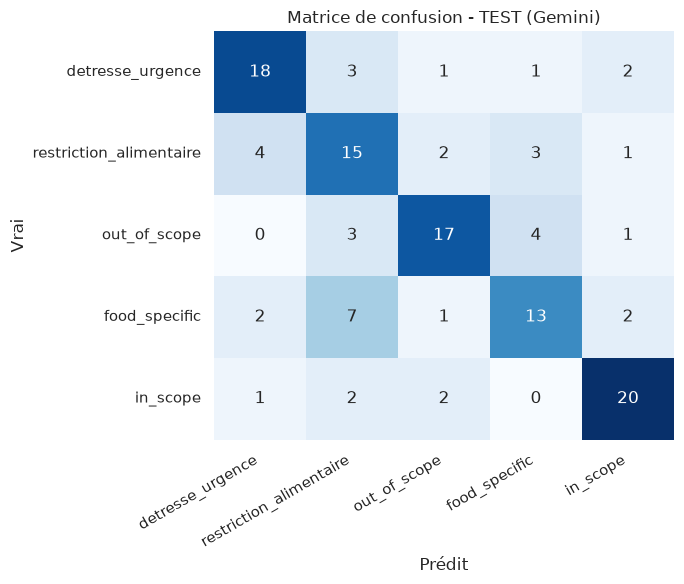

In [25]:
# Lignes = vraie classe, colonnes = prédiction. Ordre = priorité de sécurité.
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
ax.set(xlabel="Prédit", ylabel="Vrai", title="Matrice de confusion - TEST (Gemini)")
plt.xticks(rotation=30, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

In [27]:
# Un message de détresse mal routé = échec grave. On regarde le rappel des 2 classes critiques
# et, surtout, VERS QUOI partent les détresses ratées.
report = classification_report(y_test, y_pred, labels=CLASS_ORDER,
                               output_dict=True, zero_division=0)

print("Rappel par classe :")
for c in CLASS_ORDER:
    flag = "  SÉCURITÉ" if c in SAFETY_CLASSES else ""
    print(f"  {c:25s} : {report[c]['recall']:.3f}{flag}")

mask = (y_test == "detresse_urgence") & (y_pred != "detresse_urgence")
if mask.sum():
    print(f"\n{mask.sum()} détresse(s) ratée(s) :")
    for q, p in zip(X_test[mask], y_pred[mask]):
        print(f"  → classée [{p}] : {q}")
else:
    print("\nAucune détresse ratée.")

Rappel par classe :
  detresse_urgence          : 0.720  SÉCURITÉ
  restriction_alimentaire   : 0.600  SÉCURITÉ
  out_of_scope              : 0.680
  food_specific             : 0.520
  in_scope                  : 0.800

7 détresse(s) ratée(s) :
  → classée [restriction_alimentaire] : Je suis complètement paralysée par les crampes, aidez-moi s'il vous plaît.
  → classée [out_of_scope] : SOS jpp de cette souffrance de malade
  → classée [in_scope] : jcraque complet avec ces douleurs h24
  → classée [in_scope] : bjr g une douleure insuportable o ba du ventre
  → classée [food_specific] : jss a bou de force avec cet maladi
  → classée [restriction_alimentaire] : dsl de deranger mai je soufre tro koi faire
  → classée [restriction_alimentaire] : je souffre le martyre


## Filet de sécurité déterministe/detresse_urgence
Deux petites fonctions ici, contrairement à d'habitude : c'est volontaire. Ce filet est le livrable (il sera repris tel quel dans les tests pytest C12/C13)

In [29]:
def normalize(text: str) -> str:
    """Minuscule, sans accents, sans ponctuation. Recolle les graphies : 'soufre'/'souffre',
    'à bout'/'a bou' deviennent comparables. C'est ce qui rend les règles robustes aux fautes."""
    text = text.lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))  # é -> e
    text = re.sub(r"[^a-z0-9 ]", " ", text)   # apostrophes/ponctuation -> espace
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Motifs regroupés par type de signal (cf. perimetre-intentions §detresse_urgence).
# On cherche le RAPPEL maximal : mieux vaut sur-déclencher que rater une détresse.
DETRESSE_PATTERNS = [
    # -- Appel à l'aide explicite (déclencheurs durs, quasi jamais hors détresse) --
    r"\bsos\b", r"au secours", r"aid(ez|e)?[ ]?moi",
    # -- Épuisement / désespoir --
    r"\bjpp\b", r"(en|ne) peux\b.{0,12}\bplus", r"\ba bou", r"epuis",
    r"craqu", r"a quoi bon", r"pleure", r"detruit",
    r"personne ne.{0,8}comprend", r"martyr",
    # -- Douleur intense en 1re personne (avec intensité, pour ne PAS capter les questions abstraites) --
    r"trop de mal|trop mal|tro mal|si mal|tellement mal",
    r"souffr|soufr", r"insupportable|insuportable", r"pliee|plie en deux",
    r"douleur.{0,15}(horrible|insupportable|insuportable|atroce|affreuse)",
    r"mal.{0,10}(insupportable|atroce|horrible)",
    r"\bmal\b.{0,20}\bmal\b",                 # répétition : "jai mal jai mal"
    # -- Symptômes aigus / orientation urgente --
    r"evanoui", r"vertige", r"\burgence", r"\bh ?24\b",
    r"saignement.{0,15}abondant|(tres )?abondant",
]
COMPILED = [re.compile(p) for p in DETRESSE_PATTERNS]

def is_detresse(text: str) -> bool:
    """True si au moins un motif de détresse est présent."""
    t = normalize(text)
    return any(p.search(t) for p in COMPILED)

print(f"{len(DETRESSE_PATTERNS)} motifs compilés.")

25 motifs compilés.


### Mini test unitaire (la base de tes futurs pytest)

In [31]:
# Ces cas viennent de tes 7 détresses ratées par la LogReg + 2 frontières à NE PAS déclencher.
# Ils doivent tous passer. C'est le noyau de ton test de non-régression sécurité.
doivent_declencher = [
    "Je suis complètement paralysée par les crampes, aidez-moi s'il vous plaît.",
    "SOS jpp de cette souffrance de malade",
    "jcraque complet avec ces douleurs h24",
    "bjr g une douleure insuportable o ba du ventre",
    "jss a bou de force avec cet maladi",
    "dsl de deranger mai je soufre tro koi faire",
    "je souffre le martyre",
]
ne_doivent_pas = [
    "Est-ce que l'alimentation peut aider les douleurs ?",   # in_scope
    "quels aliments je dois éviter ?",                        # restriction
]

print("Doivent déclencher :")
for s in doivent_declencher:
    print(f"  {'REUSSI' if is_detresse(s) else 'RATÉ'}  {s}")
print("\nNe doivent PAS déclencher :")
for s in ne_doivent_pas:
    print(f"  {'REUSSI' if not is_detresse(s) else 'FAUX POSITIF'}  {s}")

Doivent déclencher :
  REUSSI  Je suis complètement paralysée par les crampes, aidez-moi s'il vous plaît.
  REUSSI  SOS jpp de cette souffrance de malade
  REUSSI  jcraque complet avec ces douleurs h24
  REUSSI  bjr g une douleure insuportable o ba du ventre
  REUSSI  jss a bou de force avec cet maladi
  REUSSI  dsl de deranger mai je soufre tro koi faire
  REUSSI  je souffre le martyre

Ne doivent PAS déclencher :
  REUSSI  Est-ce que l'alimentation peut aider les douleurs ?
  REUSSI  quels aliments je dois éviter ?


### Le filet sur le jeu de test : rappel et faux positifs

In [32]:
y_pred_ml = pipe.predict(X_test)                      # prédiction du modèle seul
net_fires = np.array([is_detresse(q) for q in X_test])  # le filet se déclenche-t-il ?

is_true_detresse = (y_test == "detresse_urgence")

# Rappel du filet SEUL sur la détresse
recall_net = (net_fires & is_true_detresse).sum() / is_true_detresse.sum()
print(f"Rappel du filet seul sur detresse_urgence : {recall_net:.3f} "
      f"({(net_fires & is_true_detresse).sum()}/{is_true_detresse.sum()})")

# Faux positifs : le filet se déclenche alors que la vraie classe n'est PAS détresse
fp_mask = net_fires & ~is_true_detresse
print(f"\nFaux positifs du filet : {fp_mask.sum()}")
if fp_mask.sum():
    fp_by_class = pd.Series(y_test[fp_mask]).value_counts()
    print("Répartition par vraie classe :")
    print(fp_by_class.to_string())
    print("\nPhrases concernées :")
    for q, c in zip(X_test[fp_mask], y_test[fp_mask]):
        print(f"  [{c}] {q}")

Rappel du filet seul sur detresse_urgence : 0.520 (13/25)

Faux positifs du filet : 2
Répartition par vraie classe :
restriction_alimentaire    1
out_of_scope               1

Phrases concernées :
  [restriction_alimentaire] Hier j'ai craqué sur une pâtisserie et depuis je m'en veux terriblement, je sais que je ne devrais rien avaler de sucré avec ma pathologie.
  [out_of_scope] Je prends du Sawis depuis six mois et je perds mes cheveux par poignées, est-ce que c'est un effet secondaire connu des laboratoires ?


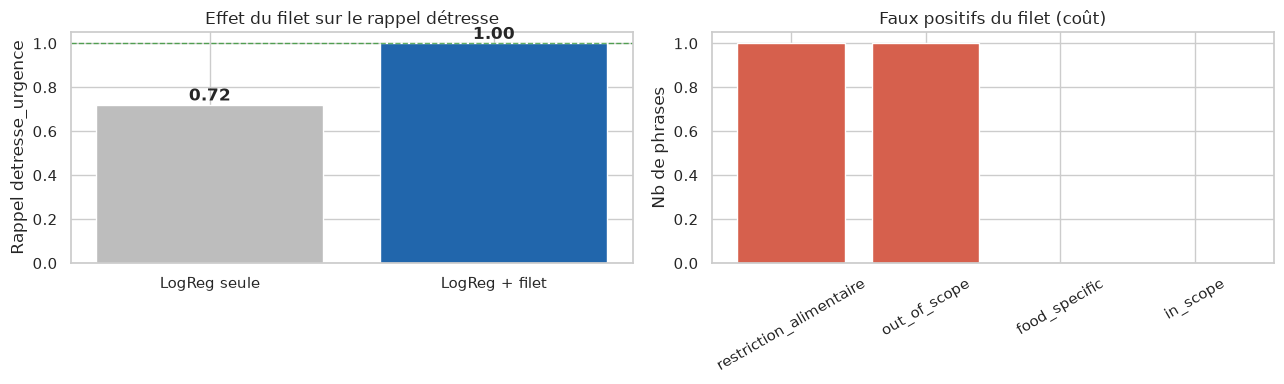

In [33]:
# Rappel détresse : modèle seul vs modèle + filet
recall_ml = ((y_pred_ml == "detresse_urgence") & is_true_detresse).sum() / is_true_detresse.sum()
recall_combined = ((net_fires | (y_pred_ml == "detresse_urgence")) & is_true_detresse).sum() / is_true_detresse.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gauche : rappel détresse avant/après
bars = axes[0].bar(["LogReg seule", "LogReg + filet"], [recall_ml, recall_combined],
                   color=["#bdbdbd", "#2166ac"])
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Rappel detresse_urgence")
axes[0].set_title("Effet du filet sur le rappel détresse")
axes[0].axhline(1.0, ls="--", lw=1, color="green", alpha=.6)
for b, v in zip(bars, [recall_ml, recall_combined]):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontweight="bold")

# Droite : faux positifs du filet par classe (le coût du sur-déclenchement)
if fp_mask.sum():
    fp_by_class = pd.Series(y_test[fp_mask]).value_counts().reindex(
        [c for c in CLASS_ORDER if c != "detresse_urgence"]).fillna(0)
    axes[1].bar(fp_by_class.index, fp_by_class.values, color="#d6604d")
    axes[1].set_title("Faux positifs du filet (coût)"); axes[1].set_ylabel("Nb de phrases")
    axes[1].tick_params(axis="x", rotation=30)
else:
    axes[1].text(0.5, 0.5, "Aucun faux positif", ha="center", va="center", fontsize=13)
    axes[1].set_axis_off()
plt.tight_layout(); plt.show()

Accuracy — LogReg seule : 0.664
Accuracy — combiné      : 0.712

                         precision    recall  f1-score   support

       detresse_urgence      0.735     1.000     0.847        25
restriction_alimentaire      0.560     0.560     0.560        25
           out_of_scope      0.773     0.680     0.723        25
          food_specific      0.650     0.520     0.578        25
               in_scope      0.833     0.800     0.816        25

               accuracy                          0.712       125
              macro avg      0.710     0.712     0.705       125
           weighted avg      0.710     0.712     0.705       125



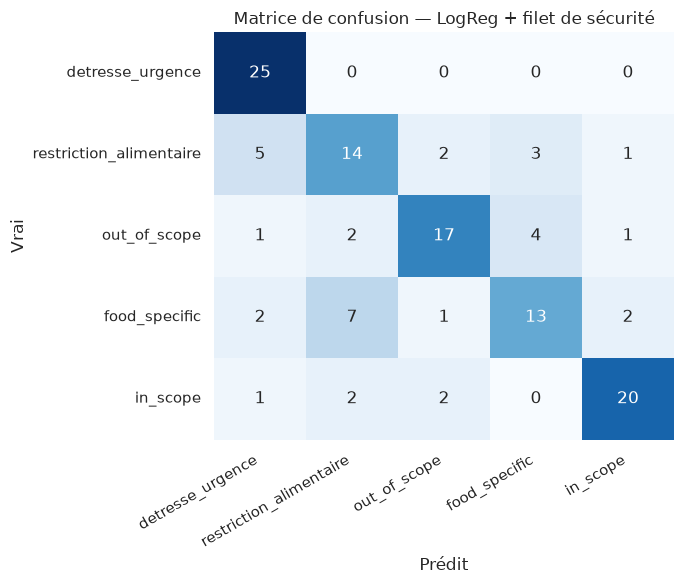

In [34]:
# Règle de combinaison : le filet PRIME. S'il se déclenche -> détresse, sinon on garde la LogReg.
y_pred_combined = np.where(net_fires, "detresse_urgence", y_pred_ml)

print(f"Accuracy — LogReg seule : {accuracy_score(y_test, y_pred_ml):.3f}")
print(f"Accuracy — combiné      : {accuracy_score(y_test, y_pred_combined):.3f}\n")
print(classification_report(y_test, y_pred_combined, labels=CLASS_ORDER, digits=3, zero_division=0))

cm = confusion_matrix(y_test, y_pred_combined, labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
ax.set(xlabel="Prédit", ylabel="Vrai", title="Matrice de confusion — LogReg + filet de sécurité")
plt.xticks(rotation=30, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## Export du modèle

In [36]:

joblib.dump(pipe, "intent_classifier.pkl")

meta = {
    "model": "TfidfVectorizer(ngram 1-2) + LogisticRegression",
    "classes": CLASS_ORDER,
    "train_size": int(len(y_train)),
    "test_size": int(len(y_test)),
    "train_generators": ["claude_opus_5", "claude_opus_4.8", "gpt_luna"],
    "test_generator": "gemini_1.5_pro",
    "metrics_test": {
        "accuracy_model": round(accuracy_score(y_test, y_pred_ml), 3),
        "accuracy_combined": round(accuracy_score(y_test, y_pred_combined), 3),
        "recall_detresse_combined": round(
            ((y_pred_combined == "detresse_urgence") & (y_test == "detresse_urgence")).sum()
            / (y_test == "detresse_urgence").sum(), 3),
    },
    "safety_net_version": "1.0",
    "sklearn_version": sklearn.__version__,   # à figer côté backend pour éviter les warnings de désérialisation
    "date": datetime.date.today().isoformat(),
}
with open("intent_classifier_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print("Exporté : intent_classifier.pkl + intent_classifier_meta.json")

Exporté : intent_classifier.pkl + intent_classifier_meta.json
